In [2]:
import struct
import numpy as np
import subprocess
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
#from tqdm.notebook import tqdm # Progress bar
from matplotlib import colormaps as cm

In [3]:
TSTEP = 0.0001

In [4]:
FIGURE_FOLDER = 'figures/'
DATA_FOLDER = 'out/'

In [12]:
KILLRANGE = [1e-6,50]
# Run our C code by calling the shell with arguments
def getTrajectory(v0_vec, N=10_000, tstep=0.001, 
                  method='fr_pv', x0=[0.0,0.058],
                  fname = 'tmp.bin'):
    filename = DATA_FOLDER + fname
#    v0_vec = [v0*np.cos(theta), v0*np.sin(theta)]
    result = subprocess.run(['./simulation',
                             '-v', '%f,%f' % tuple(v0_vec), # Set Velocity
                             '-r', '%f,%f' % tuple(x0), # Set Position
                             '-n', '%d'    % N, # Num steps
                             '-t', '%f'    % tstep, # Step-size
                             '-s', '%d'    % 1, # Save skip (save every %d),
                             #'-k', '%f,%f' % tuple(KILLRANGE),
                             '-o', filename, # Output file name
                             '-b', '1', # Enable binary output (because fast)
                             '-m', method,  # Choose our method here
                             '-f', 'circular_restricted'],   # Choice of CR3BP force,
                           capture_output=True)
    return read_binary_file(filename) # Read back the output, return it

# Read the output file generated by our C code
def read_binary_file(filename):
    with open(filename, 'rb') as file:
        numSteps, numColumns = struct.unpack('ii', file.read(8))
        data = []
        # Read the input array (first "column")
        inputArray = np.fromfile(file, dtype=np.double, count=numSteps)
        data.append(inputArray)
        # Read each subsequent data array ("column")
        for _ in range(numColumns):
            dataArray = np.fromfile(file, dtype=np.double, count=numSteps)
            data.append(dataArray)
    return data

In [13]:
# Function to increase font size of "tick" labels
def bigTicks(size=14):
    plt.gca().tick_params(axis='both', which='major', labelsize=size)
    
def drawAxisLines(**kwargs):
    ax = plt.gca()
    args = {}
    args['color'] = 'k'
    args['alpha'] = 0.5
    args['lw'] = 1
    for k,v in kwargs.items():
        args[k] = v
    ax.axhline(y=0, **args)
    ax.axvline(x=0, **args)
    
# Standardize the saving of plots
def savefig(savename, img_format='.svg'):
    kwargs = {}
    kwargs.setdefault('bbox_inches', 'tight')
    if(img_format == '.png'):
        kwargs['dpi'] = 300
    plt.savefig(FIGURE_FOLDER + savename + img_format, **kwargs)
    
#Slice up the plot and give a diffent color for each
def plotSliced(x, y, numSlices=100, color_vect=[1,0,0], 
                                   color_range=[0.25,1.0],
                                   color_curv = 0.01,
                                   alpha_range=[1,1],
                                   overlap_int = 1):
    N = len(x)
    N_C = numSlices #Number of slices
    crng = np.array(color_range)*color_curv
    cr = np.geomspace(*crng,N_C)/color_curv # Green color range
    ar = np.geomspace(*alpha_range,N_C) # Green color range
    slices = np.round(np.linspace(0,N,N_C)[:-1]).astype(int)
    plotstep = round(N/N_C)+overlap_int
    for i in range(N_C-1):
        ps = plotstep
        if(ar[i] > 0.6):
            ps = plotstep+1
        ind = slices[i]
        plt.plot(x[ind:ind+ps], y[ind:ind+ps],alpha=ar[i],
                                        color=np.array(color_vect)*cr[i])

In [14]:
# Rotation matrix with (t)->(-t) 
def rotatePaths(x,y,t):
    return [ np.cos(t)*x + np.sin(t)*y, 
            -np.sin(t)*x + np.cos(t)*y]

In [15]:
def plot_rot(vxi, vyi, r_init, TSTEPsing = 0.001, nper=25):
    plt.figure(figsize=(6,6))
    plt.axis('scaled')
    drawAxisLines(alpha=0.3)
    R_INIT = r_init

    #plotSliced([rm1[0][-1]],[rm1[1][-1]], color_vect=(1,0,0))
    #plotSliced([rm2[0][-1]],[rm2[1][-1]], color_vect=(1,0,0))

    plotOpts = {'alpha_range' : [1,1],
                'color_range' : [0.8,.8],
                'numSlices' : 1000,
                'overlap_int' : 0}

    simOpts = {'tstep' : TSTEPsing,
               'N'     : nper*np.pi//TSTEPsing,
               'x0' : R_INIT}

    dat = getTrajectory([vxi,vyi], **simOpts)
    t, x, y, vx, vy = dat
    x_rot, y_rot = rotatePaths(x,y,t)
    #plotSliced(x_rot, y_rot, color_vect=[0,1,0], **plotOpts)
    plt.plot(x_rot, y_rot, c='tab:green')


    #plt.plot([x_rot[-1]],[y_rot[-1]], 'o', c='red')
    #plt.plot([x[0]],[y[0]], 'o', c='blue')

    plt.xlabel("$x(t)$", size=18)
    plt.ylabel("$y(t)$", size=18)
    bigTicks()
    zoom = 1.1
    plt.xlim(-zoom, zoom)
    plt.ylim(-zoom/2, zoom/2)
    plt.title(f'{R_INIT=} {vxi=} {vyi=}')
    
def plot_stat(vxi, vyi, r_init, TSTEPsing = 0.001, nper=65):
    plt.figure(figsize=(6,6))
    plt.axis('scaled')
    drawAxisLines(alpha=0.3)
    R_INIT = r_init

    #plotSliced([rm1[0][-1]],[rm1[1][-1]], color_vect=(1,0,0))
    #plotSliced([rm2[0][-1]],[rm2[1][-1]], color_vect=(1,0,0))

    plotOpts = {'alpha_range' : [1,1],
                'color_range' : [0.8,.8],
                'numSlices' : 1000,
                'overlap_int' : 0}

    simOpts = {'tstep' : TSTEPsing,
               'N'     : nper*np.pi//TSTEPsing,
               'x0' : R_INIT}

    dat = getTrajectory([vxi,vyi], **simOpts)
    t, x, y, vx, vy = dat
    #x_rot, y_rot = rotatePaths(x,y,t)
    #plotSliced(x_rot, y_rot, color_vect=[0,1,0], **plotOpts)
    plt.plot(x, y, c='tab:green')


    #plt.plot([x_rot[-1]],[y_rot[-1]], 'o', c='red')
    #plt.plot([x[0]],[y[0]], 'o', c='blue')

    plt.xlabel("$x(t)$", size=18)
    plt.ylabel("$y(t)$", size=18)
    bigTicks()
    zoom = 1.1
    plt.xlim(-zoom, zoom)
    plt.ylim(-zoom, zoom)
    plt.title(f'{R_INIT=} {vxi=} {vyi=}')

# Single Orbit Simulator

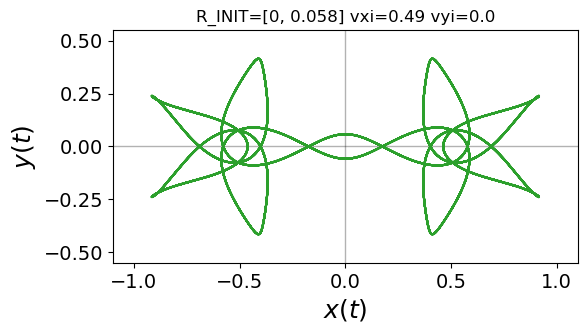

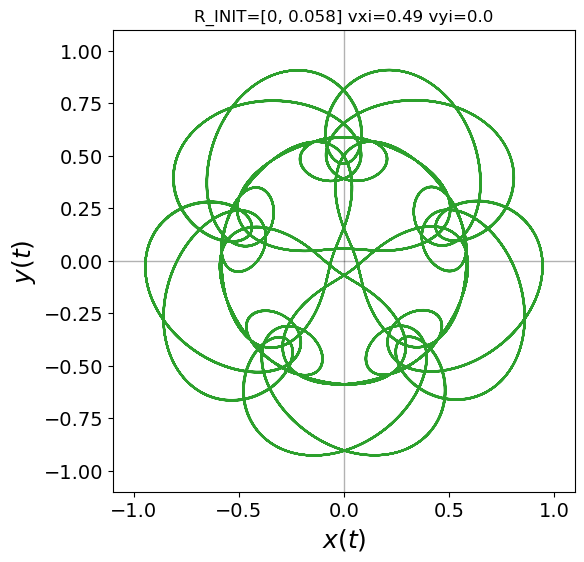

In [16]:
vxi=0.49
vyi = 0.0
R_INIT = [0, 0.058]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)

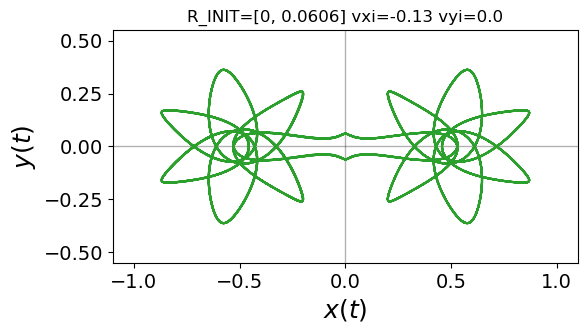

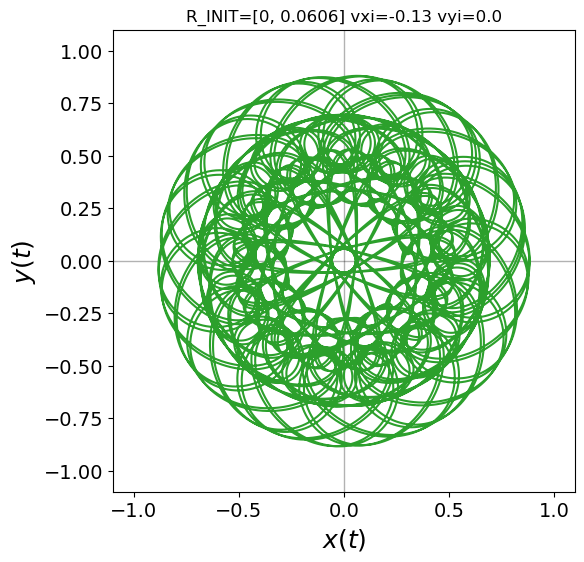

In [17]:
vxi=-0.13
vyi = 0.0
R_INIT = [0, 0.0606]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)

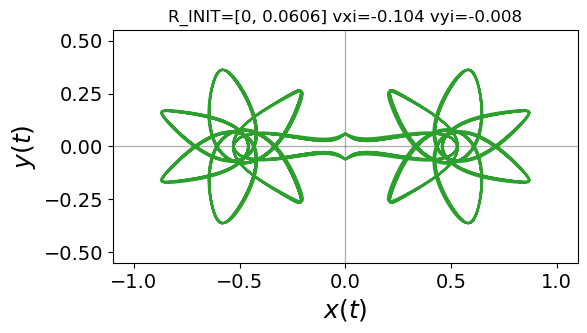

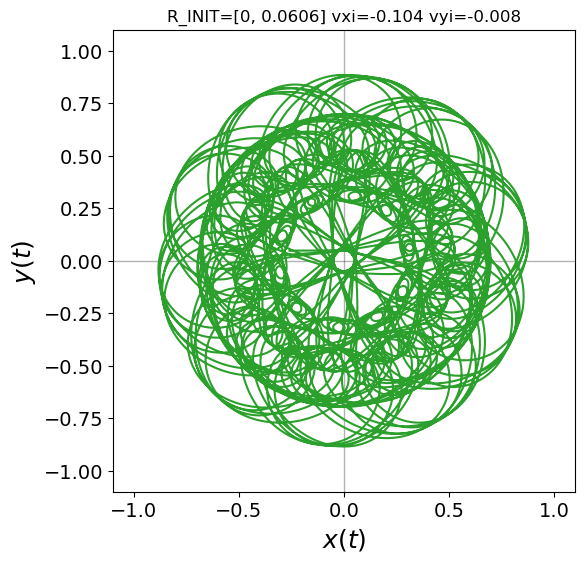

In [18]:
vxi=-0.104
vyi = -0.008
R_INIT = [0, 0.0606]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

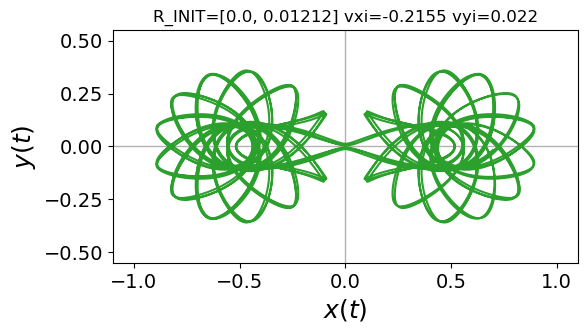

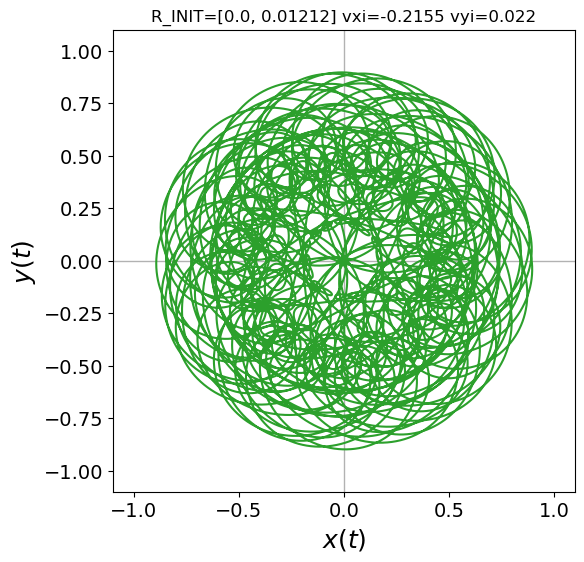

In [19]:
vxi=-0.2155
vyi = .022#0021530612411246191
R_INIT = [0.0, 0.01212]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT,nper=60)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

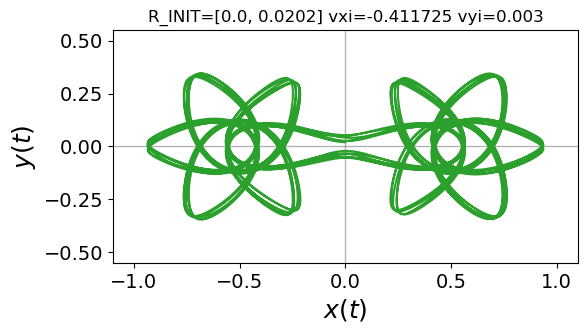

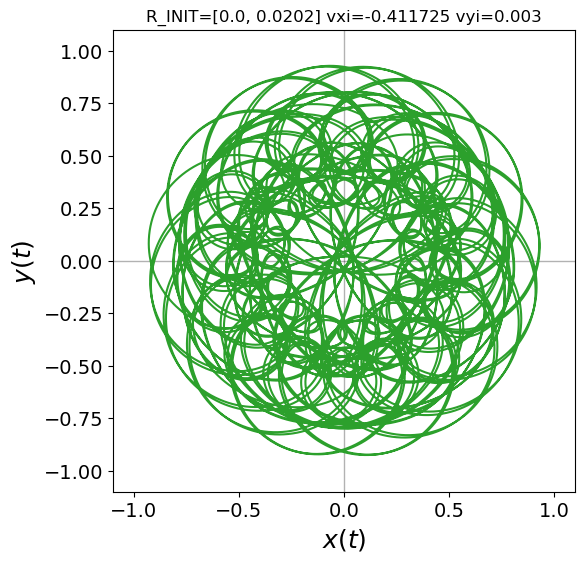

In [20]:
vxi= -.411725
vyi = 0.003
R_INIT = [0.0, 0.0202]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

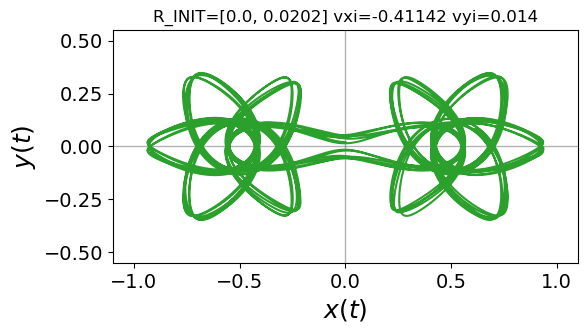

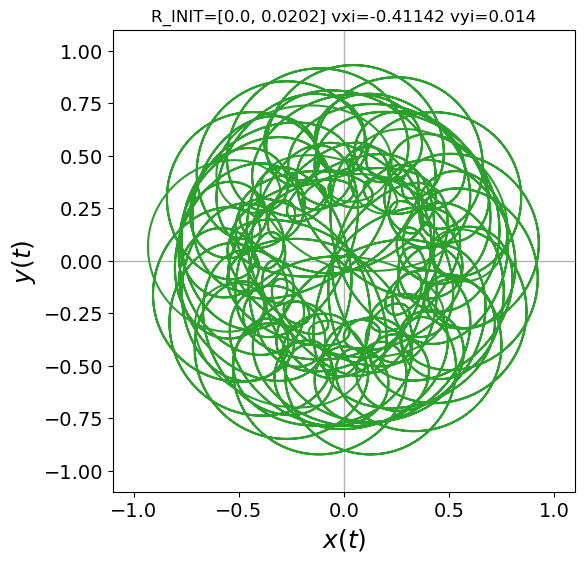

In [21]:
vxi= -.41142
vyi = 0.014
R_INIT = [0.0, 0.0202]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

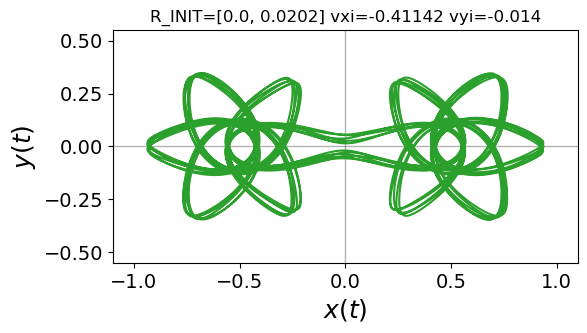

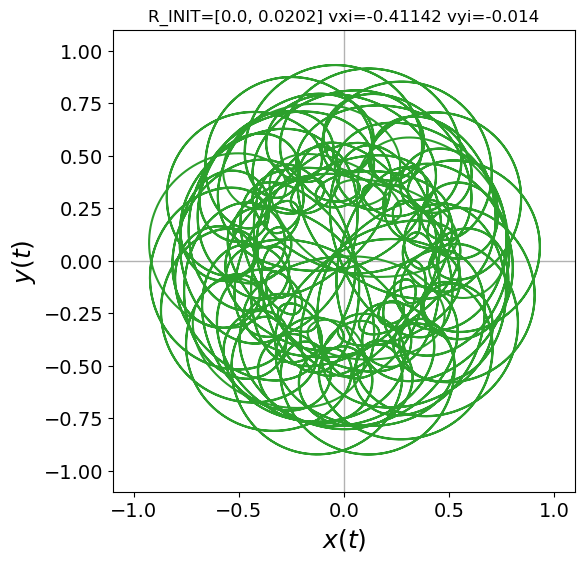

In [22]:
vxi= -.41142
vyi = -0.014
R_INIT = [0.0, 0.0202]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

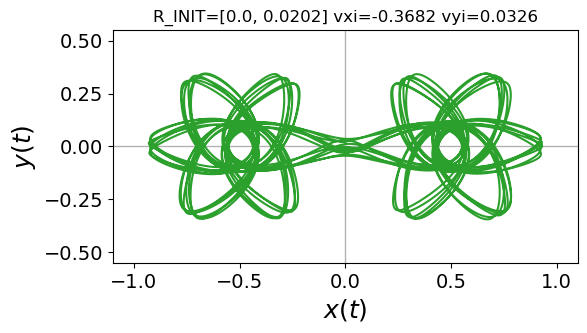

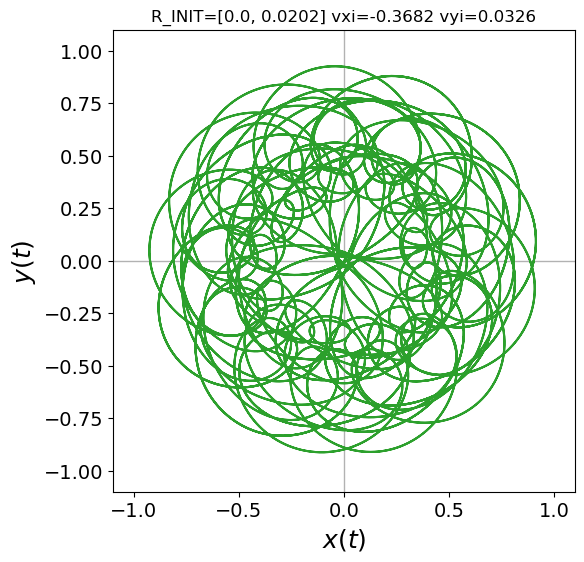

In [23]:
vxi= -.3682
vyi = 0.0326
R_INIT = [0.0, 0.0202]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

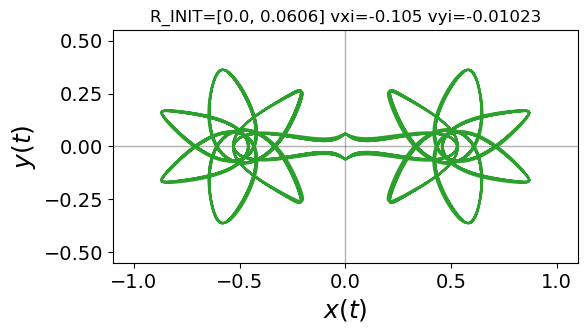

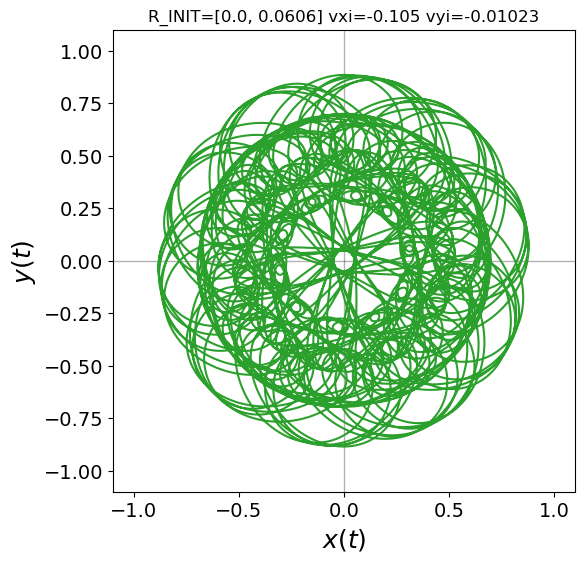

In [24]:
vxi= -0.105
vyi = -.01023
R_INIT = [0.0, 0.0606]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

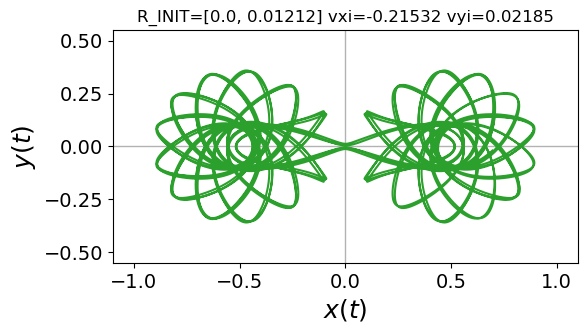

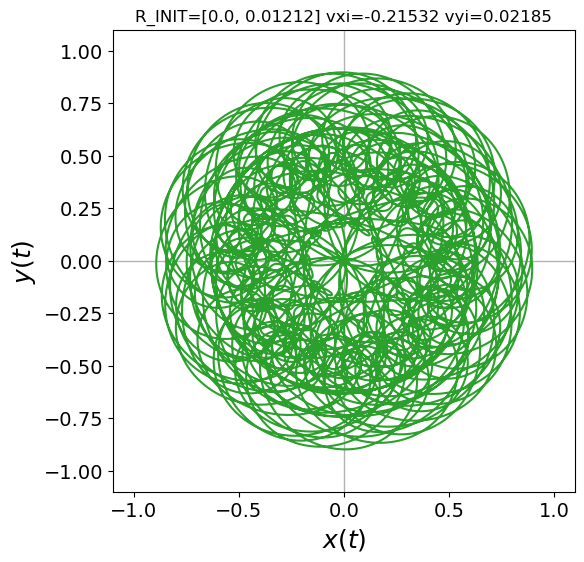

In [25]:
vxi= -.21532
vyi = .02185
R_INIT = [0.0, 0.01212]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

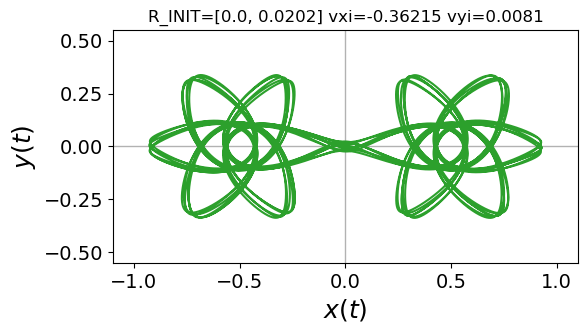

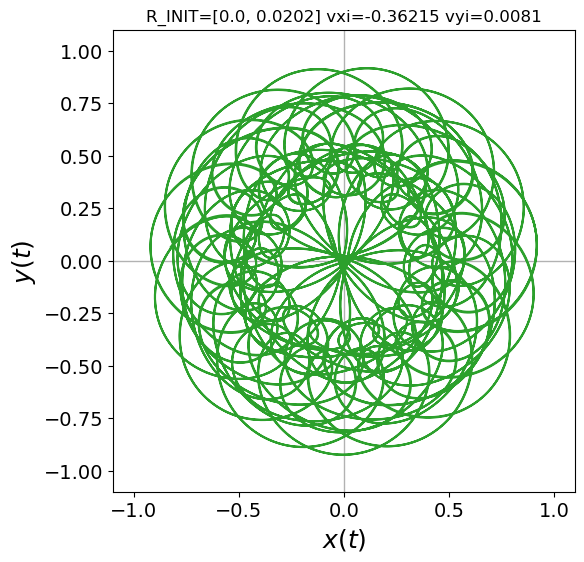

In [26]:
vxi, vyi = [-.36215, .0081]
R_INIT = [0.0, 0.0202]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

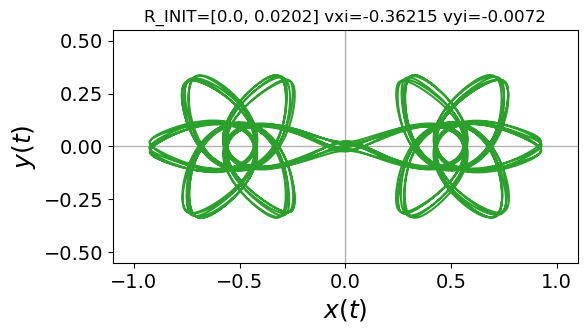

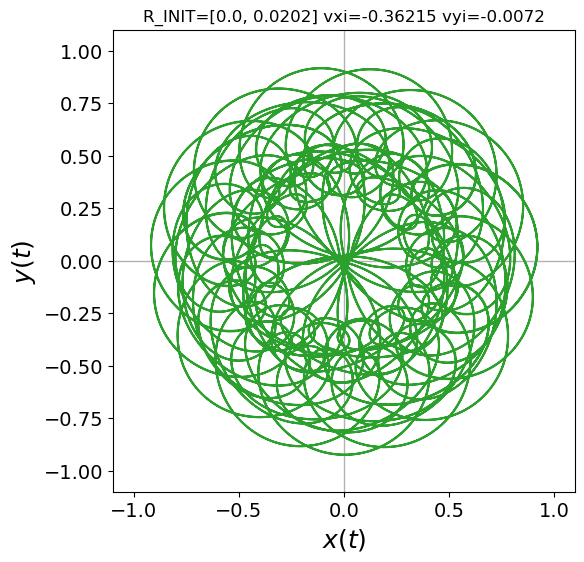

In [27]:

vxi, vyi = [-.36215, -.0072]
R_INIT = [0.0, 0.0202]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

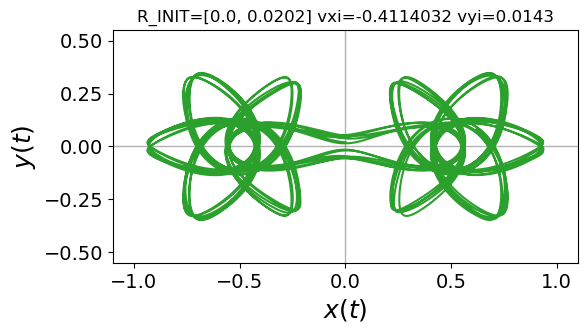

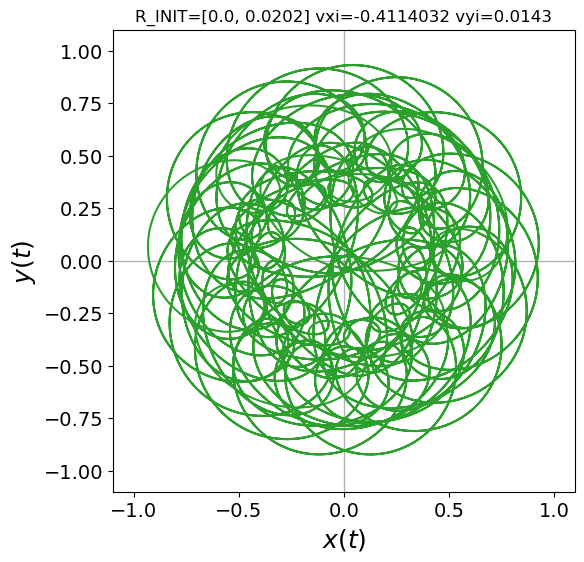

In [28]:
vxi, vyi = [-.4114032, 0.0143]
R_INIT = [0.0, 0.0202]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

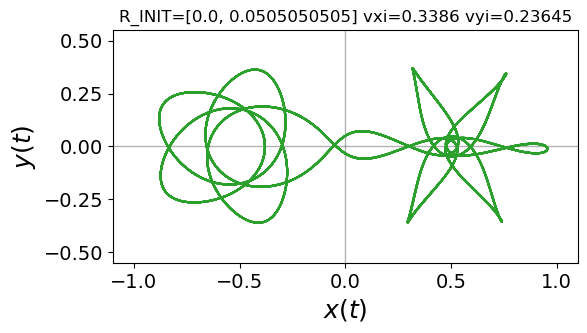

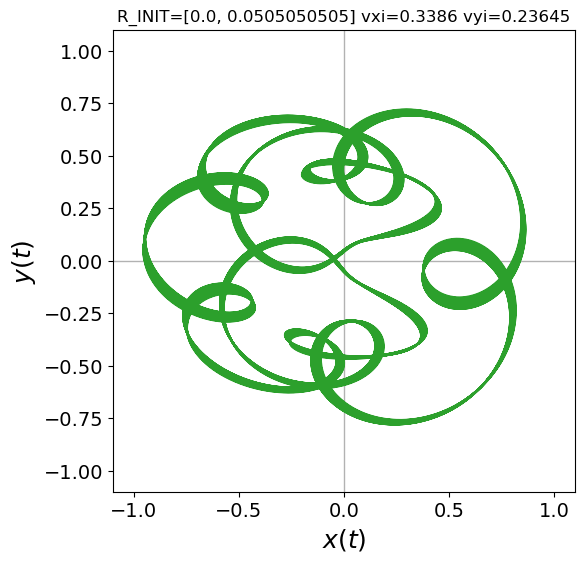

In [29]:
vxi, vyi = [.3386, .23645]
#vxi, vyi = [.34055, .23365]
R_INIT = [0.0, 0.0505050505]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

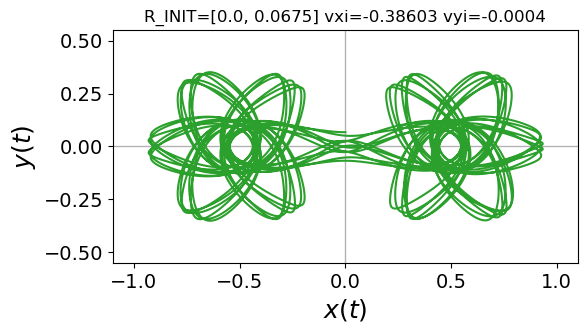

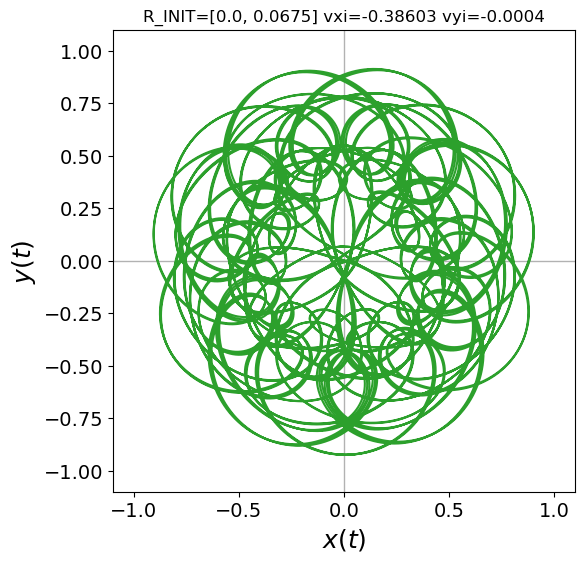

In [30]:
vxi, vyi = [-.38603, -0.0004]
R_INIT = [0.0, 0.0675]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

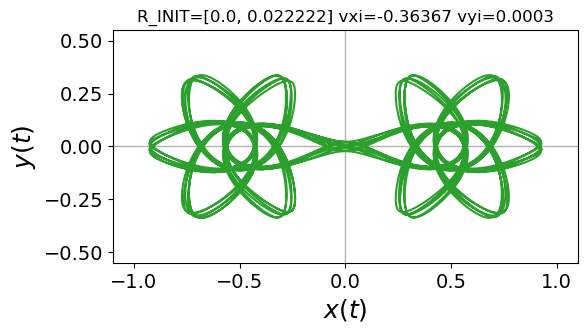

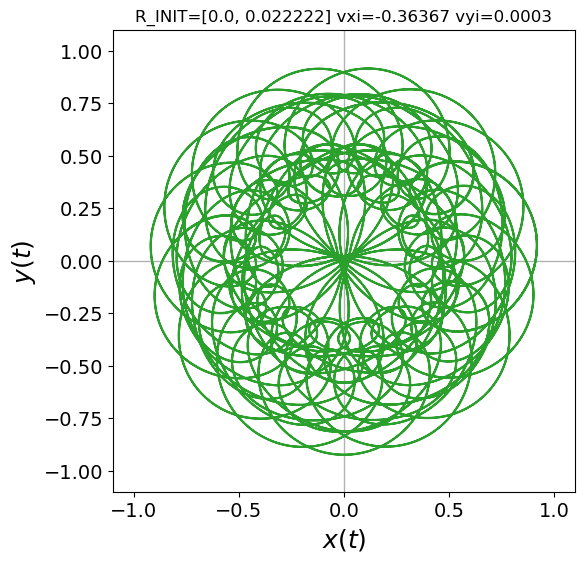

In [31]:
vxi, vyi = [-.36367, 0.0003]
R_INIT = [0.0, 0.022222]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

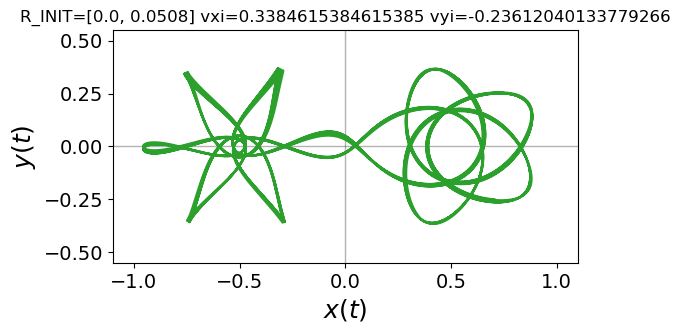

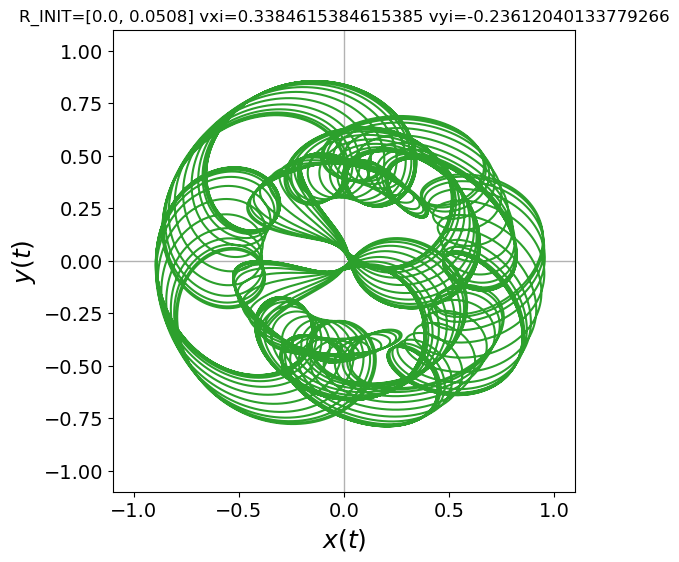

In [32]:
vxi, vyi = [0.3384615384615385, -0.23612040133779266]
R_INIT = [0.0, 0.0508]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

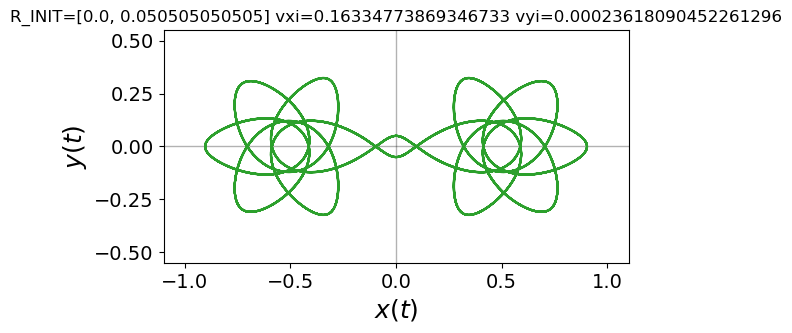

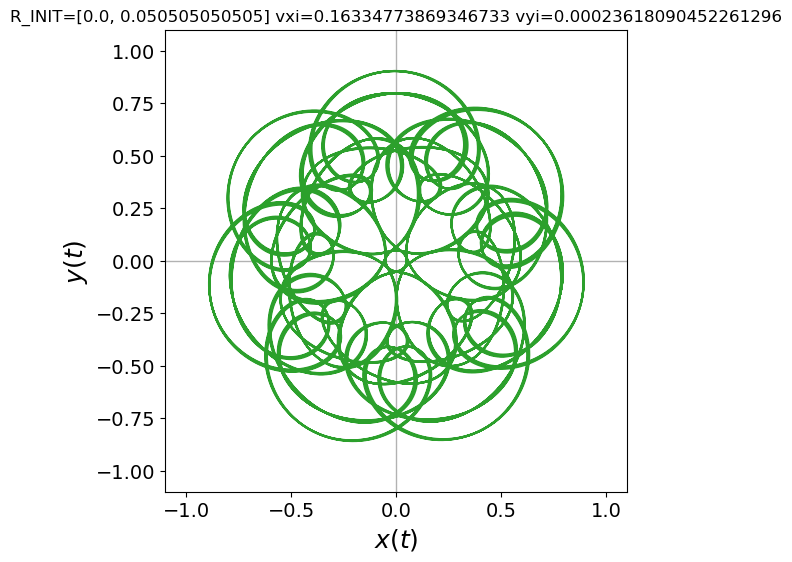

In [33]:
vxi, vyi = [0.16334773869346733, 0.00023618090452261296]
R_INIT = [0.0, 0.050505050505]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

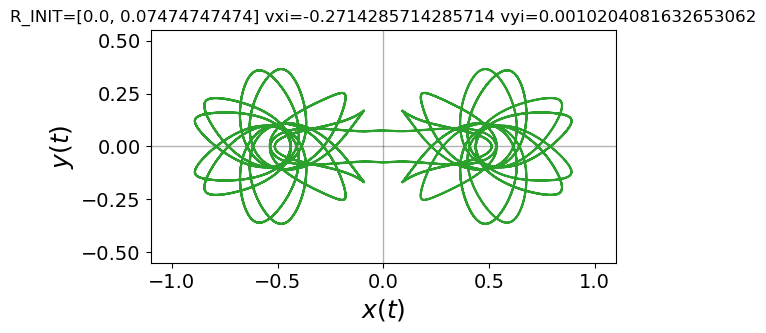

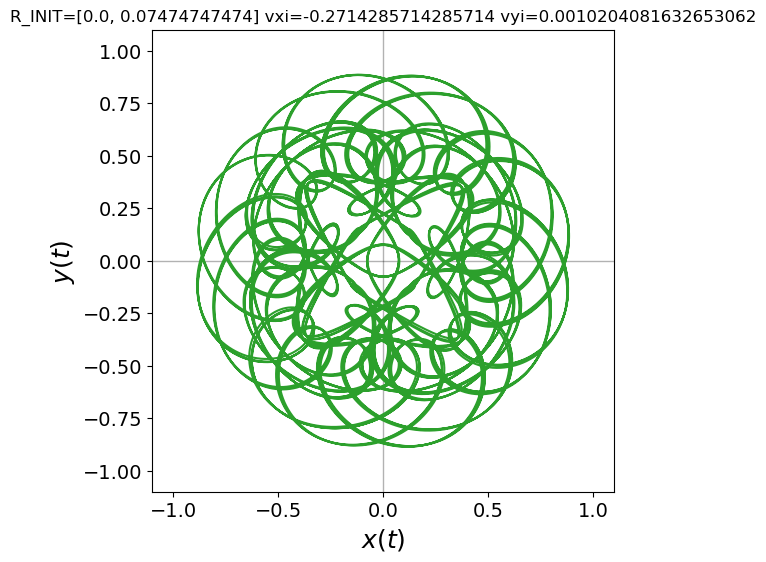

In [34]:
vxi, vyi = [-0.2714285714285714, 0.0010204081632653062]
R_INIT = [0.0, 0.07474747474]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)

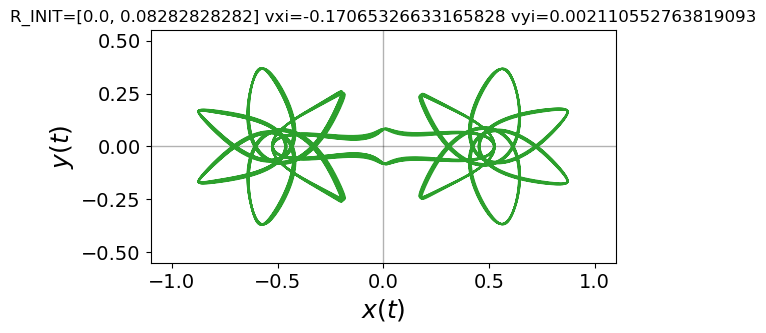

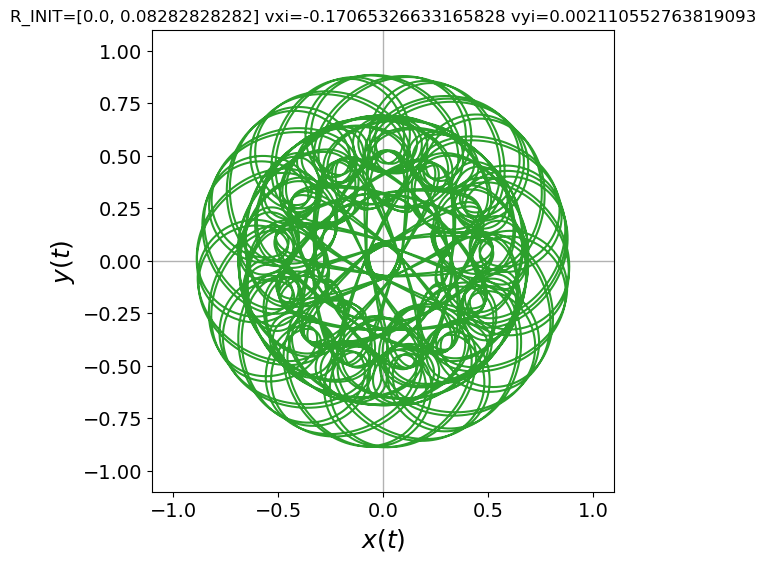

In [35]:
vxi, vyi = [-0.17065326633165828, 0.002110552763819093]
R_INIT = [0.0, 0.08282828282]
plot_rot(vxi, vyi, R_INIT)
plot_stat(vxi, vyi, R_INIT)
fname = f'{R_INIT} {vxi} {vyi}'
savefig(fname)